In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from outlier_cleaner import OutlierCleaner

# Preprocessing and pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


# Sklearn libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor,
    VotingRegressor, StackingRegressor
)

# Sklearn metrics
from sklearn.metrics import r2_score, mean_squared_error
from extended_sklearn_metrics import evaluate_model_with_cross_validation

# Extra model
import xgboost as xgb

In [2]:
# Load the csv
df = pd.read_csv('./student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
# Check everything before start
df.shape

(1000, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [8]:
# so from here we have 91 missing values

In [9]:
df['parental_education_level'].value_counts()

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64

## Replace missing values with unknown

In [11]:
df.loc[df['parental_education_level'].isnull(), 'parental_education_level'] = 'Unknown'

In [12]:
# Replace with mode
# mode = df['parental_education_level'].mode()
# df.dropna(subset=['parental_education_level'], inplace=True)

In [13]:
# Drop it
# df.dropna(['parental_education_level'], inplace=True)

In [14]:
# replace with unknown instead of drop or replace with mode/median

In [15]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

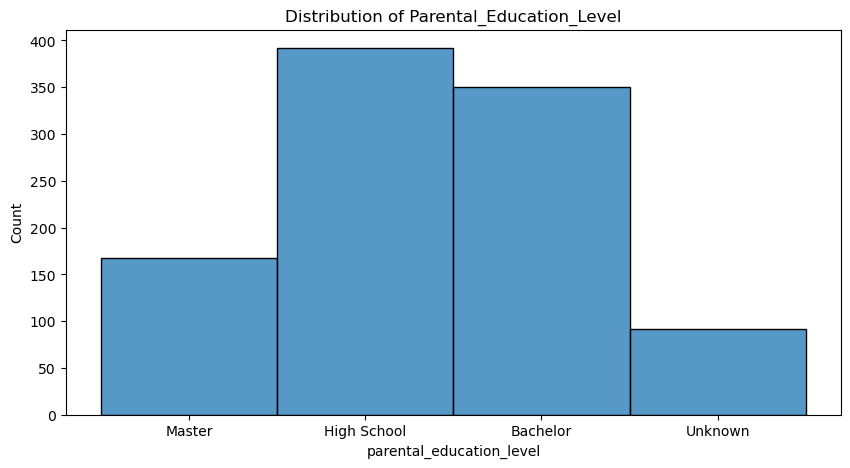

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['parental_education_level'])
plt.title('Distribution of Parental_Education_Level')
plt.show()

## EDA (Quick overview everything)

In [18]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

## Numeric Features

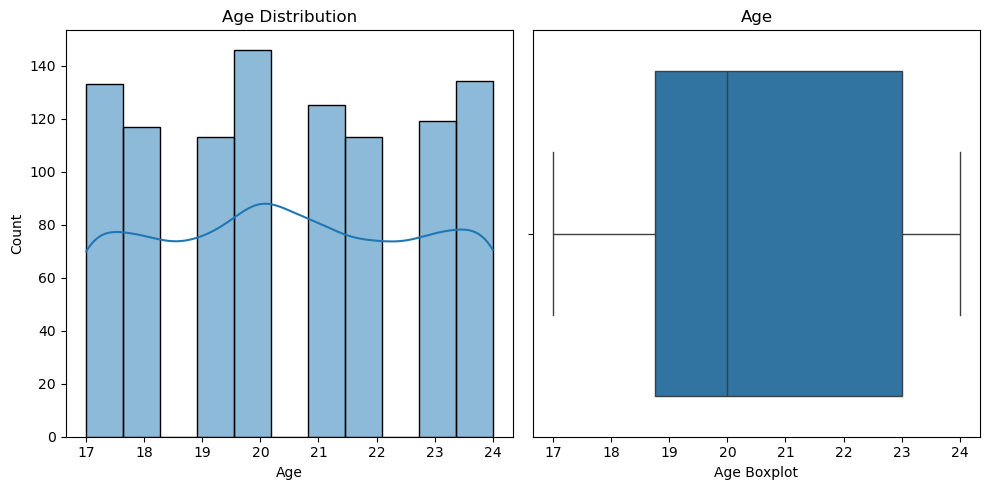

In [20]:
# age
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='age', kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='age')
plt.title('Age')
plt.xlabel('Age Boxplot')
plt.tight_layout()
plt.show()

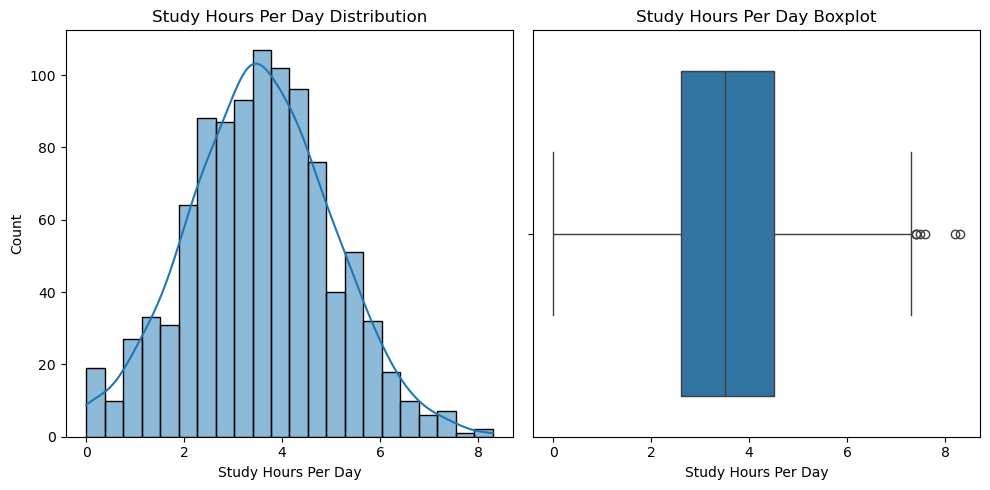

In [21]:
# study_hours_per_day
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='study_hours_per_day', kde=True)
plt.title('Study Hours Per Day Distribution')
plt.xlabel('Study Hours Per Day')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='study_hours_per_day')
plt.title('Study Hours Per Day Boxplot')
plt.xlabel('Study Hours Per Day')
plt.tight_layout()
plt.show()

In [22]:
# df.columns

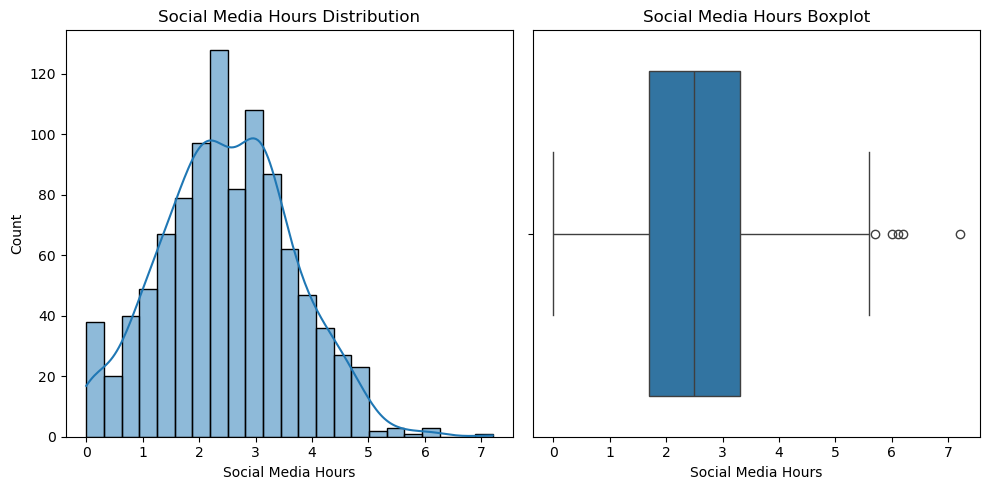

In [23]:
# social_media_hours
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='social_media_hours', kde=True)
plt.title('Social Media Hours Distribution')
plt.xlabel('Social Media Hours')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='social_media_hours')
plt.title('Social Media Hours Boxplot')
plt.xlabel('Social Media Hours')
plt.tight_layout()
plt.show()

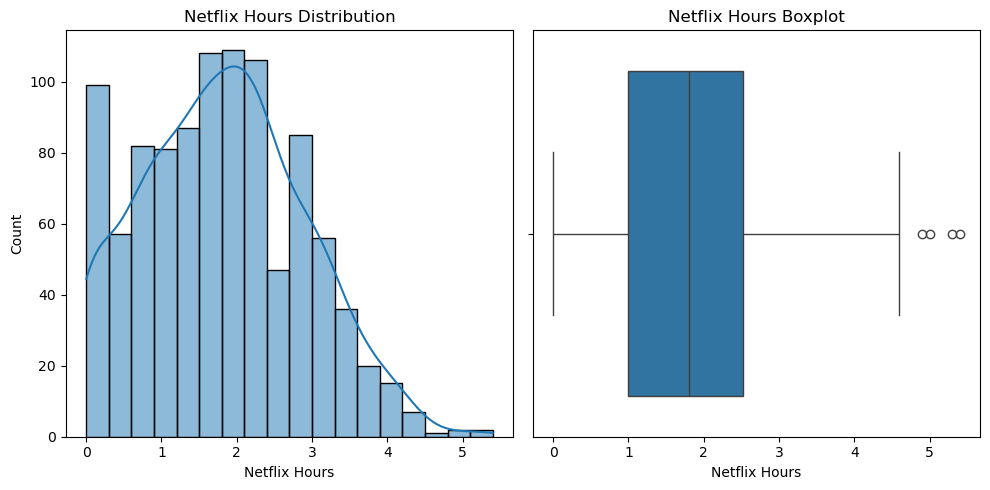

In [24]:
# netflix_hours
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='netflix_hours', kde=True)
plt.title('Netflix Hours Distribution')
plt.xlabel('Netflix Hours')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='netflix_hours')
plt.title('Netflix Hours Boxplot')
plt.xlabel('Netflix Hours')
plt.tight_layout()
plt.show()

In [25]:
# df.columns

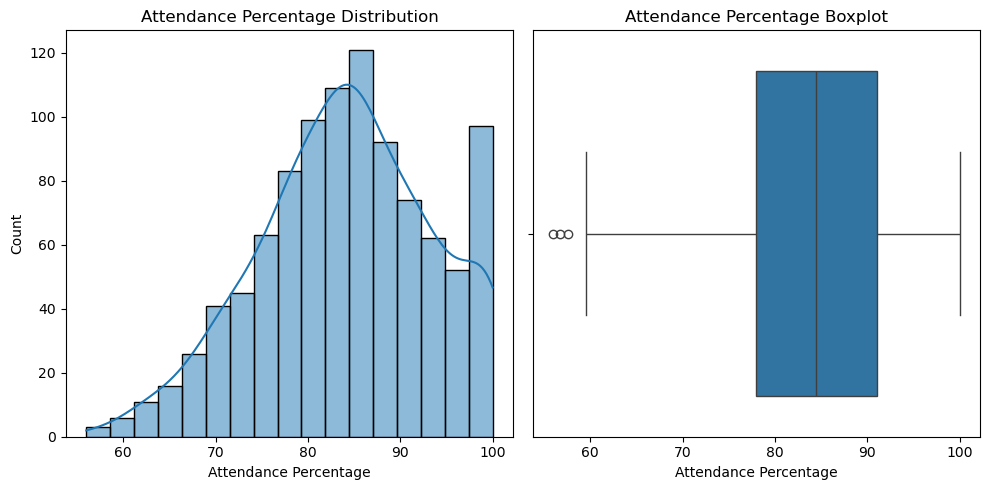

In [26]:
# attendance_percentage
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='attendance_percentage', kde=True)
plt.title('Attendance Percentage Distribution')
plt.xlabel('Attendance Percentage')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='attendance_percentage')
plt.title('Attendance Percentage Boxplot')
plt.xlabel('Attendance Percentage')
plt.tight_layout()
plt.show()

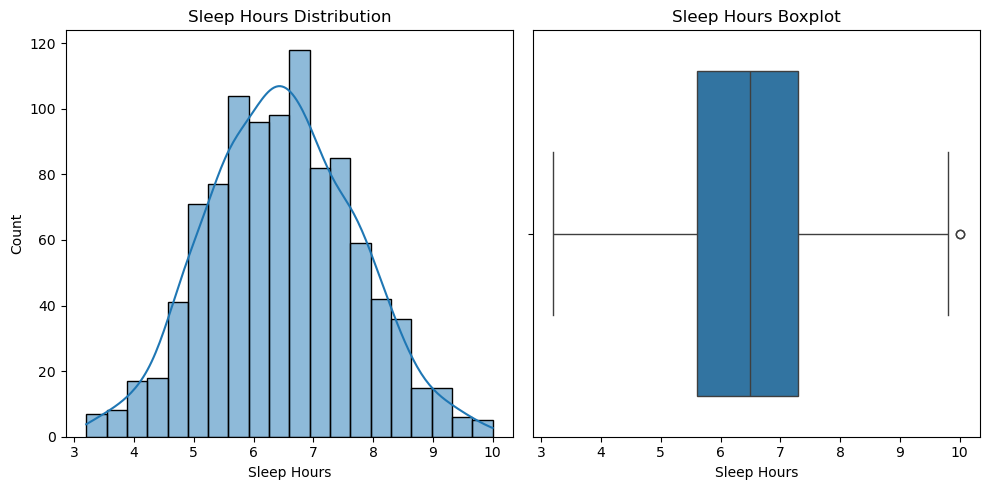

In [27]:
# sleep_hours
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='sleep_hours', kde=True)
plt.title('Sleep Hours Distribution')
plt.xlabel('Sleep Hours')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='sleep_hours')
plt.title('Sleep Hours Boxplot')
plt.xlabel('Sleep Hours')
plt.tight_layout()
plt.show()

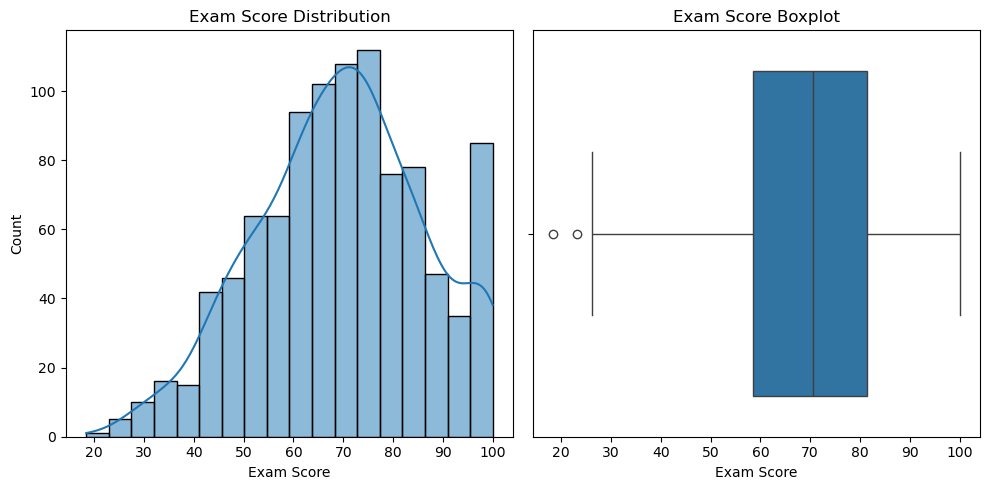

In [28]:
# exam_score
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='exam_score', kde=True)
plt.title('Exam Score Distribution')
plt.xlabel('Exam Score')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='exam_score')
plt.title('Exam Score Boxplot')
plt.xlabel('Exam Score')
plt.tight_layout()
plt.show()

## Skewness

In [30]:
# df.columns

In [31]:
numeric_cols = ['age','study_hours_per_day','social_media_hours','netflix_hours','attendance_percentage', 'sleep_hours','exam_score']
df[numeric_cols].skew()

age                      0.008437
study_hours_per_day      0.054253
social_media_hours       0.119805
netflix_hours            0.237154
attendance_percentage   -0.237810
sleep_hours              0.091484
exam_score              -0.156351
dtype: float64

## Categorical features (Plot and unique values)

In [33]:
# df.columns

In [34]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

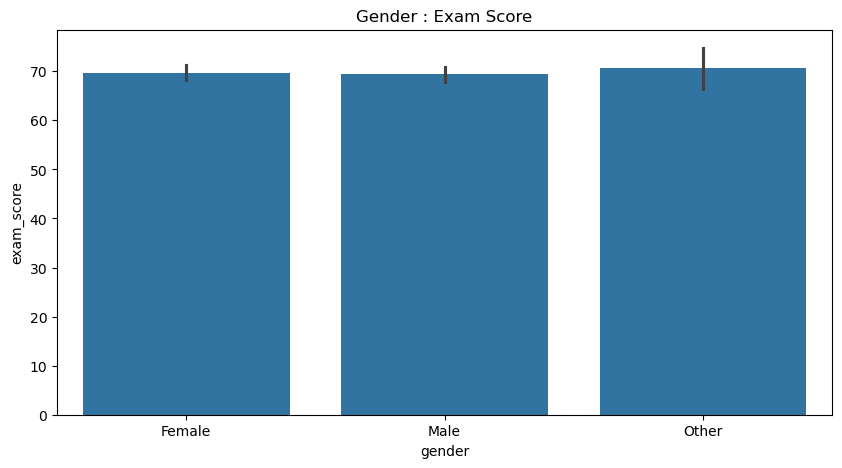

In [35]:
# Gender
plt.figure(figsize=(10,5))
sns.barplot(df, x='gender', y='exam_score')
plt.title('Gender : Exam Score')
plt.show()

In [36]:
df['part_time_job'].unique()

array(['No', 'Yes'], dtype=object)

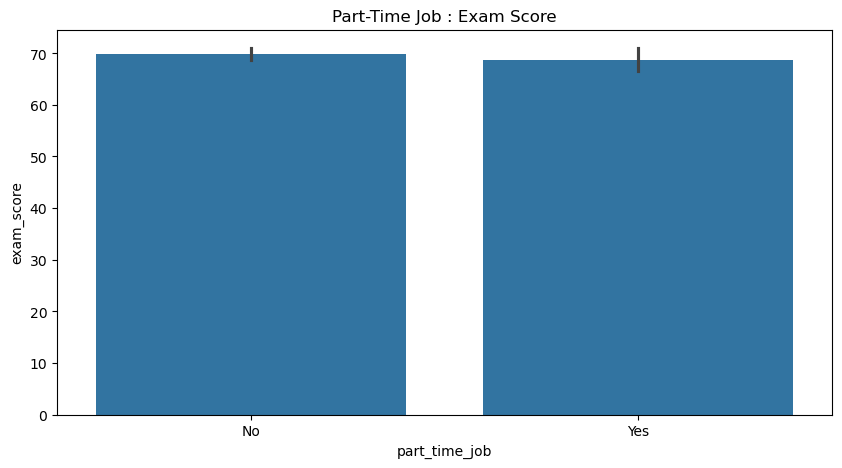

In [37]:
# Part time
plt.figure(figsize=(10,5))
sns.barplot(df, x='part_time_job', y='exam_score')
plt.title('Part-Time Job : Exam Score')
plt.show()

In [38]:
df['diet_quality'].unique()

array(['Fair', 'Good', 'Poor'], dtype=object)

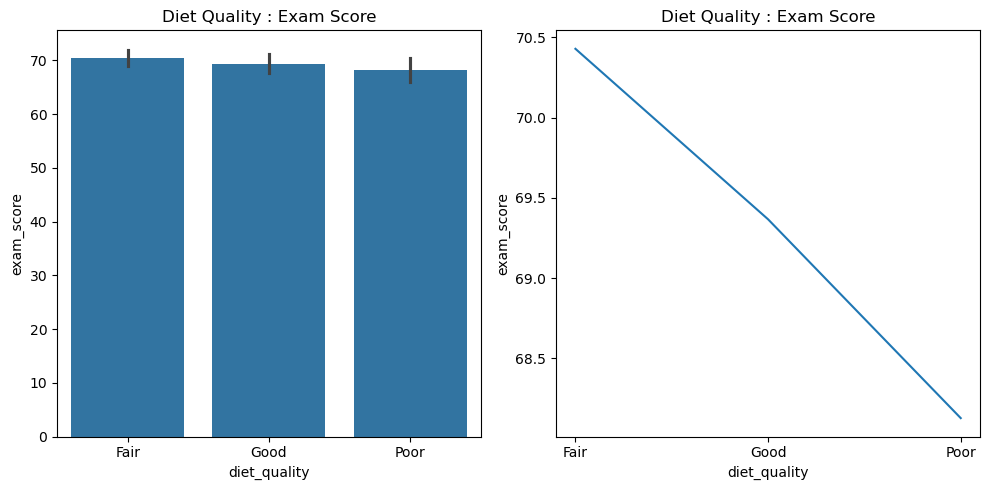

In [39]:
# Diet
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.barplot(df, x='diet_quality', y='exam_score')
plt.title('Diet Quality : Exam Score')

plt.subplot(1, 2, 2)
avg_diet = df.groupby('diet_quality')['exam_score'].mean().reset_index()
sns.lineplot(avg_diet, x='diet_quality', y='exam_score')
plt.title('Diet Quality : Exam Score')
plt.tight_layout()
plt.show()

In [40]:
df['exercise_frequency'].unique()

array([6, 1, 4, 3, 2, 0, 5], dtype=int64)

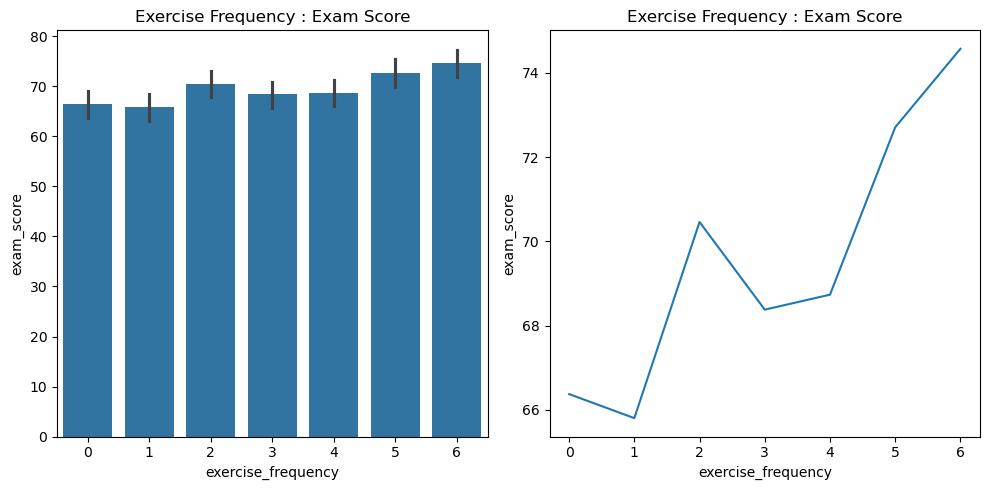

In [41]:
# Exercise
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.barplot(df, x='exercise_frequency', y='exam_score')
plt.title('Exercise Frequency : Exam Score')

plt.subplot(1, 2, 2)
avg_exercise = df.groupby('exercise_frequency')['exam_score'].mean().reset_index()
sns.lineplot(avg_exercise, x='exercise_frequency', y='exam_score')
plt.title('Exercise Frequency : Exam Score')
plt.tight_layout()
plt.show()

In [42]:
df['parental_education_level'].unique()

array(['Master', 'High School', 'Bachelor', 'Unknown'], dtype=object)

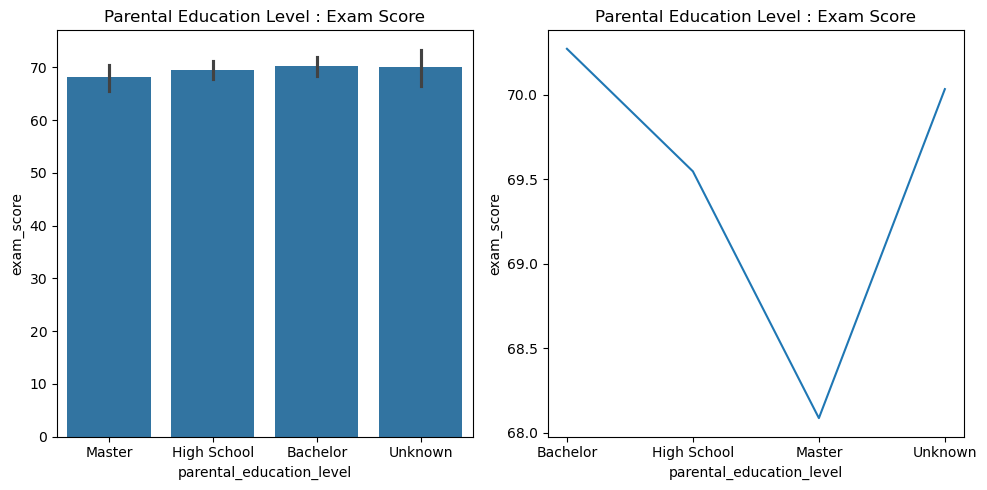

In [43]:
# Education
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.barplot(df, x='parental_education_level', y='exam_score')
plt.title('Parental Education Level : Exam Score')

plt.subplot(1, 2, 2)
avg_education = df.groupby('parental_education_level')['exam_score'].mean().reset_index()
sns.lineplot(avg_education, x='parental_education_level', y='exam_score')
plt.title('Parental Education Level : Exam Score')
plt.tight_layout()
plt.show()

In [44]:
df['internet_quality'].unique()

array(['Average', 'Poor', 'Good'], dtype=object)

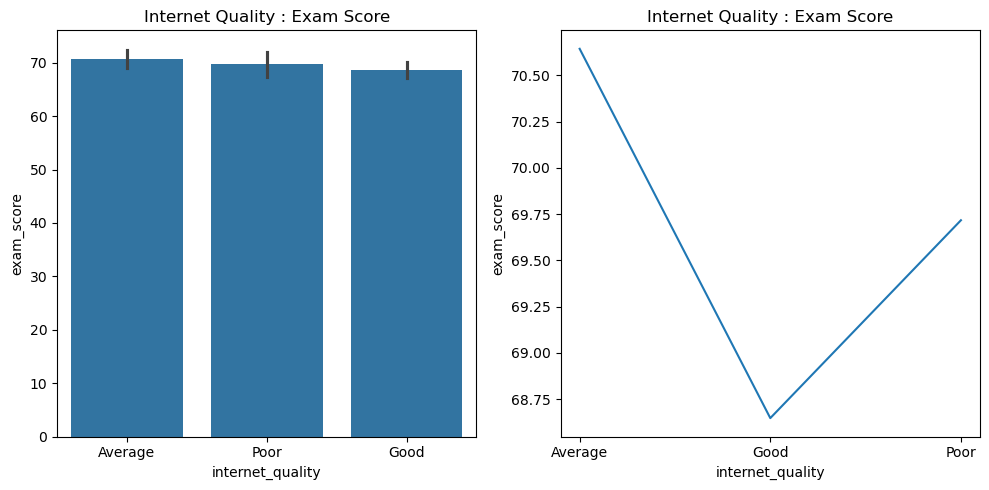

In [45]:
# Internet
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.barplot(df, x='internet_quality', y='exam_score')
plt.title('Internet Quality : Exam Score')

plt.subplot(1, 2, 2)
avg_internet = df.groupby('internet_quality')['exam_score'].mean().reset_index()
sns.lineplot(avg_internet, x='internet_quality', y='exam_score')
plt.title('Internet Quality : Exam Score')
plt.tight_layout()
plt.show()

In [46]:
df['mental_health_rating'].unique()

array([ 8,  1,  4, 10,  3,  9,  7,  5,  2,  6], dtype=int64)

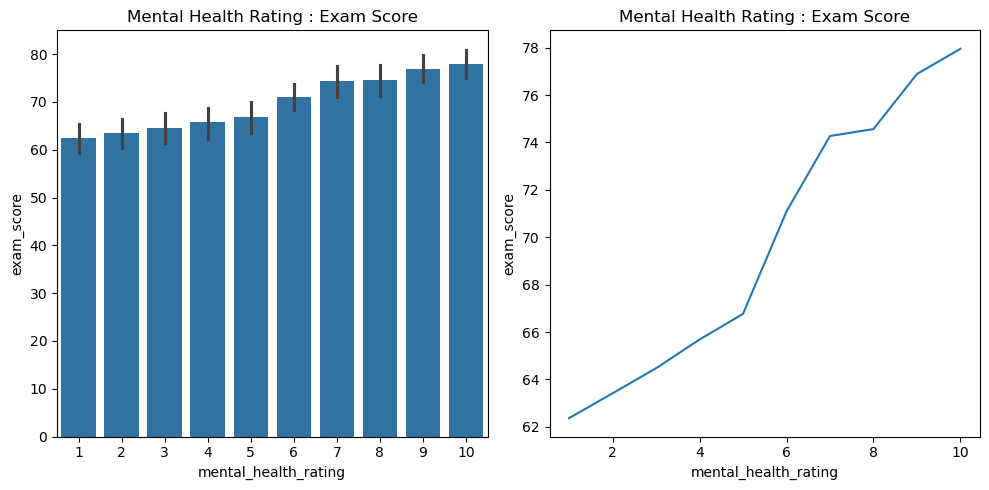

In [47]:
# Health
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.barplot(df, x='mental_health_rating', y='exam_score')
plt.title('Mental Health Rating : Exam Score')

plt.subplot(1, 2, 2)
avg_health = df.groupby('mental_health_rating')['exam_score'].mean().reset_index()
sns.lineplot(avg_health, x='mental_health_rating', y='exam_score')
plt.title('Mental Health Rating : Exam Score')
plt.tight_layout()
plt.show()

In [48]:
df['extracurricular_participation'].unique()

array(['Yes', 'No'], dtype=object)

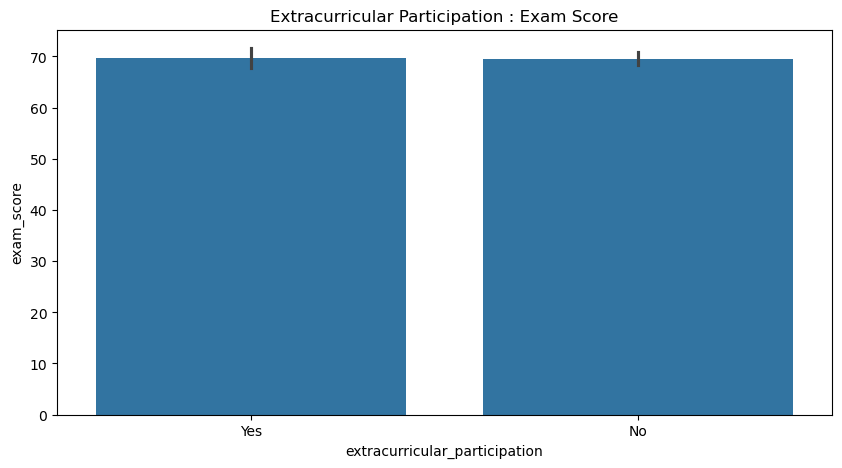

In [49]:
# Extracurricular
plt.figure(figsize=(10,5))
sns.barplot(df, x='extracurricular_participation', y='exam_score')
plt.title('Extracurricular Participation : Exam Score')
plt.show()

## Encoding

In [51]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [52]:
df = df.drop(columns=['student_id']) 
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [53]:
# clean the outlier
cleaner = OutlierCleaner(df)
numerical_features = df.select_dtypes(include=['int64', 'float64', 'int32'])
df, info = cleaner.clean_columns(
    columns = numerical_features,
    method = 'zscore',
    show_progress = True
)

Cleaning columns:   1%|          | 9/1000 [00:00<00:00, 1111.73it/s]


In [54]:
df.columns

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'exam_score'],
      dtype='object')

In [55]:
ordinal_cols = ['part_time_job', 'diet_quality', 'exercise_frequency','parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']
nominal_cols = ['gender']
encoder = LabelEncoder()
encoder_hot = OneHotEncoder(sparse_output=False)
for col in ordinal_cols:
    df[col + '_encoded'] = encoder.fit_transform(df[col])
encoded_data = encoder_hot.fit_transform(df[nominal_cols])
encoded_feature_names = encoder_hot.get_feature_names_out(nominal_cols)
nominal_df = pd.DataFrame(encoded_data, columns=encoded_feature_names)
df2 = pd.concat([df.reset_index(drop=True), nominal_df.reset_index(drop=True)], axis=1)
df2 = df2.drop(columns=['part_time_job', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation','gender'])
encoded_df = df2.select_dtypes(include=['int64', 'float64', 'int32'])
encoded_df

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exam_score,part_time_job_encoded,diet_quality_encoded,exercise_frequency_encoded,parental_education_level_encoded,internet_quality_encoded,mental_health_rating_encoded,extracurricular_participation_encoded,gender_Female,gender_Male,gender_Other
0,23,0.0,1.2,1.1,85.0,8.0,56.2,0,0,6,2,0,7,1,1.0,0.0,0.0
1,20,6.9,2.8,2.3,97.3,4.6,100.0,0,1,6,1,0,7,0,1.0,0.0,0.0
2,21,1.4,3.1,1.3,94.8,8.0,34.3,0,2,1,1,2,0,0,0.0,1.0,0.0
3,23,1.0,3.9,1.0,71.0,9.2,26.8,0,2,4,2,1,0,1,1.0,0.0,0.0
4,19,5.0,4.4,0.5,90.9,4.9,66.4,0,0,3,2,1,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,21,2.6,0.5,1.6,77.0,7.5,76.1,0,0,2,1,1,5,1,1.0,0.0,0.0
988,17,2.9,1.0,2.4,86.0,6.8,65.9,1,2,1,1,0,5,1,1.0,0.0,0.0
989,20,3.0,2.6,1.3,61.9,6.5,64.4,0,1,5,0,1,8,1,0.0,1.0,0.0
990,24,5.4,4.1,1.1,100.0,7.6,69.7,1,0,0,0,0,0,0,0.0,1.0,0.0


In [56]:
encoded_df.isna().any()

age                                      False
study_hours_per_day                      False
social_media_hours                       False
netflix_hours                            False
attendance_percentage                    False
sleep_hours                              False
exam_score                               False
part_time_job_encoded                    False
diet_quality_encoded                     False
exercise_frequency_encoded               False
parental_education_level_encoded         False
internet_quality_encoded                 False
mental_health_rating_encoded             False
extracurricular_participation_encoded    False
gender_Female                            False
gender_Male                              False
gender_Other                             False
dtype: bool

In [57]:
encoded_df.duplicated().any()

False

In [58]:
encoded_df.columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exam_score',
       'part_time_job_encoded', 'diet_quality_encoded',
       'exercise_frequency_encoded', 'parental_education_level_encoded',
       'internet_quality_encoded', 'mental_health_rating_encoded',
       'extracurricular_participation_encoded', 'gender_Female', 'gender_Male',
       'gender_Other'],
      dtype='object')

## EDA

## Correlation Heatmap

In [61]:
corma = encoded_df.corr()
cormax = corma['exam_score'].sort_values(ascending=False)
cormax

exam_score                               1.000000
study_hours_per_day                      0.824307
mental_health_rating_encoded             0.319113
exercise_frequency_encoded               0.152952
sleep_hours                              0.124239
attendance_percentage                    0.088507
gender_Female                            0.016695
gender_Other                             0.012758
extracurricular_participation_encoded   -0.006180
age                                     -0.011105
gender_Male                             -0.021844
parental_education_level_encoded        -0.028263
internet_quality_encoded                -0.029373
part_time_job_encoded                   -0.029515
diet_quality_encoded                    -0.050932
social_media_hours                      -0.164083
netflix_hours                           -0.167123
Name: exam_score, dtype: float64

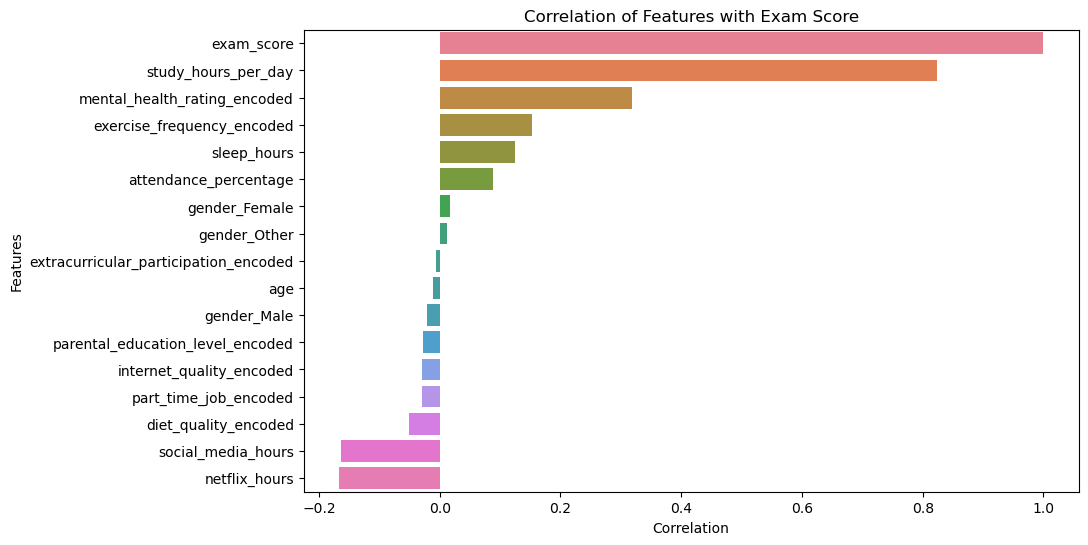

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cormax.values, y=cormax.index, hue=cormax.index)
plt.title('Correlation of Features with Exam Score')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

## Key Analysis Question

- 1. What factors most influence students' exam scores?
- 2. How strongly do academic habits (study hours, attendance) affect exam scores?
- 3. How do non-academic behaviors (social media usage, Netflix time, sleep patterns) impact exam scores?
- 4. Does family background (parental education level, internet quality at home) impact exam scores?
- 5. How does mental health relate to exam scores?

In [64]:
# Ques 1 : What factors most influence students' exam scores?

In [65]:
encoded_df.columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exam_score',
       'part_time_job_encoded', 'diet_quality_encoded',
       'exercise_frequency_encoded', 'parental_education_level_encoded',
       'internet_quality_encoded', 'mental_health_rating_encoded',
       'extracurricular_participation_encoded', 'gender_Female', 'gender_Male',
       'gender_Other'],
      dtype='object')

In [66]:
corr1 = encoded_df[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'diet_quality_encoded', 'exercise_frequency_encoded', 'parental_education_level_encoded', 'internet_quality_encoded', 'mental_health_rating_encoded', 'part_time_job_encoded', 'exam_score']].corr()
corr1

,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality_encoded,exercise_frequency_encoded,parental_education_level_encoded,internet_quality_encoded,mental_health_rating_encoded,part_time_job_encoded,exam_score
study_hours_per_day,1.000000,0.023837,-0.027636,0.024766,-0.026648,-0.074233,-0.035924,0.027204,-0.022978,-0.010456,-0.034839,0.824307
social_media_hours,0.023837,1.000000,0.003324,0.037690,0.021721,0.027555,-0.032397,0.022447,0.022271,-0.001422,0.016794,-0.164083
netflix_hours,-0.027636,0.003324,1.000000,0.001854,-0.011618,0.026614,-0.003318,-0.017189,-0.026247,0.013591,0.009620,-0.167123
attendance_percentage,0.024766,0.037690,0.001854,1.000000,0.015544,-0.005453,-0.008941,0.005647,0.038577,-0.020918,-0.042875,0.088507
sleep_hours,-0.026648,0.021721,-0.011618,0.015544,1.000000,0.020599,0.020557,-0.018775,-0.011734,-0.003169,0.003116,0.124239
diet_quality_encoded,-0.074233,0.027555,0.026614,-0.005453,0.020599,1.000000,0.042532,0.017297,-0.022743,0.060216,0.003649,-0.050932
exercise_frequency_encoded,-0.035924,-0.032397,-0.003318,-0.008941,0.020557,0.042532,1.000000,-0.028161,0.007437,-0.005083,-0.022902,0.152952
parental_education_level_encoded,0.027204,0.022447,-0.017189,0.005647,-0.018775,0.017297,-0.028161,1.000000,-0.006072,-0.092803,0.013092,-0.028263
internet_quality_encoded,-0.022978,0.022271,-0.026247,0.038577,-0.011734,-0.022743,0.007437,-0.006072,1.000000,-0.016720,-0.069479,-0.029373
mental_health_rating_encoded,-0.010456,-0.001422,0.013591,-0.020918,-0.003169,0.060216,-0.005083,-0.092803,-0.016720,1.000000,0.010360,0.319113


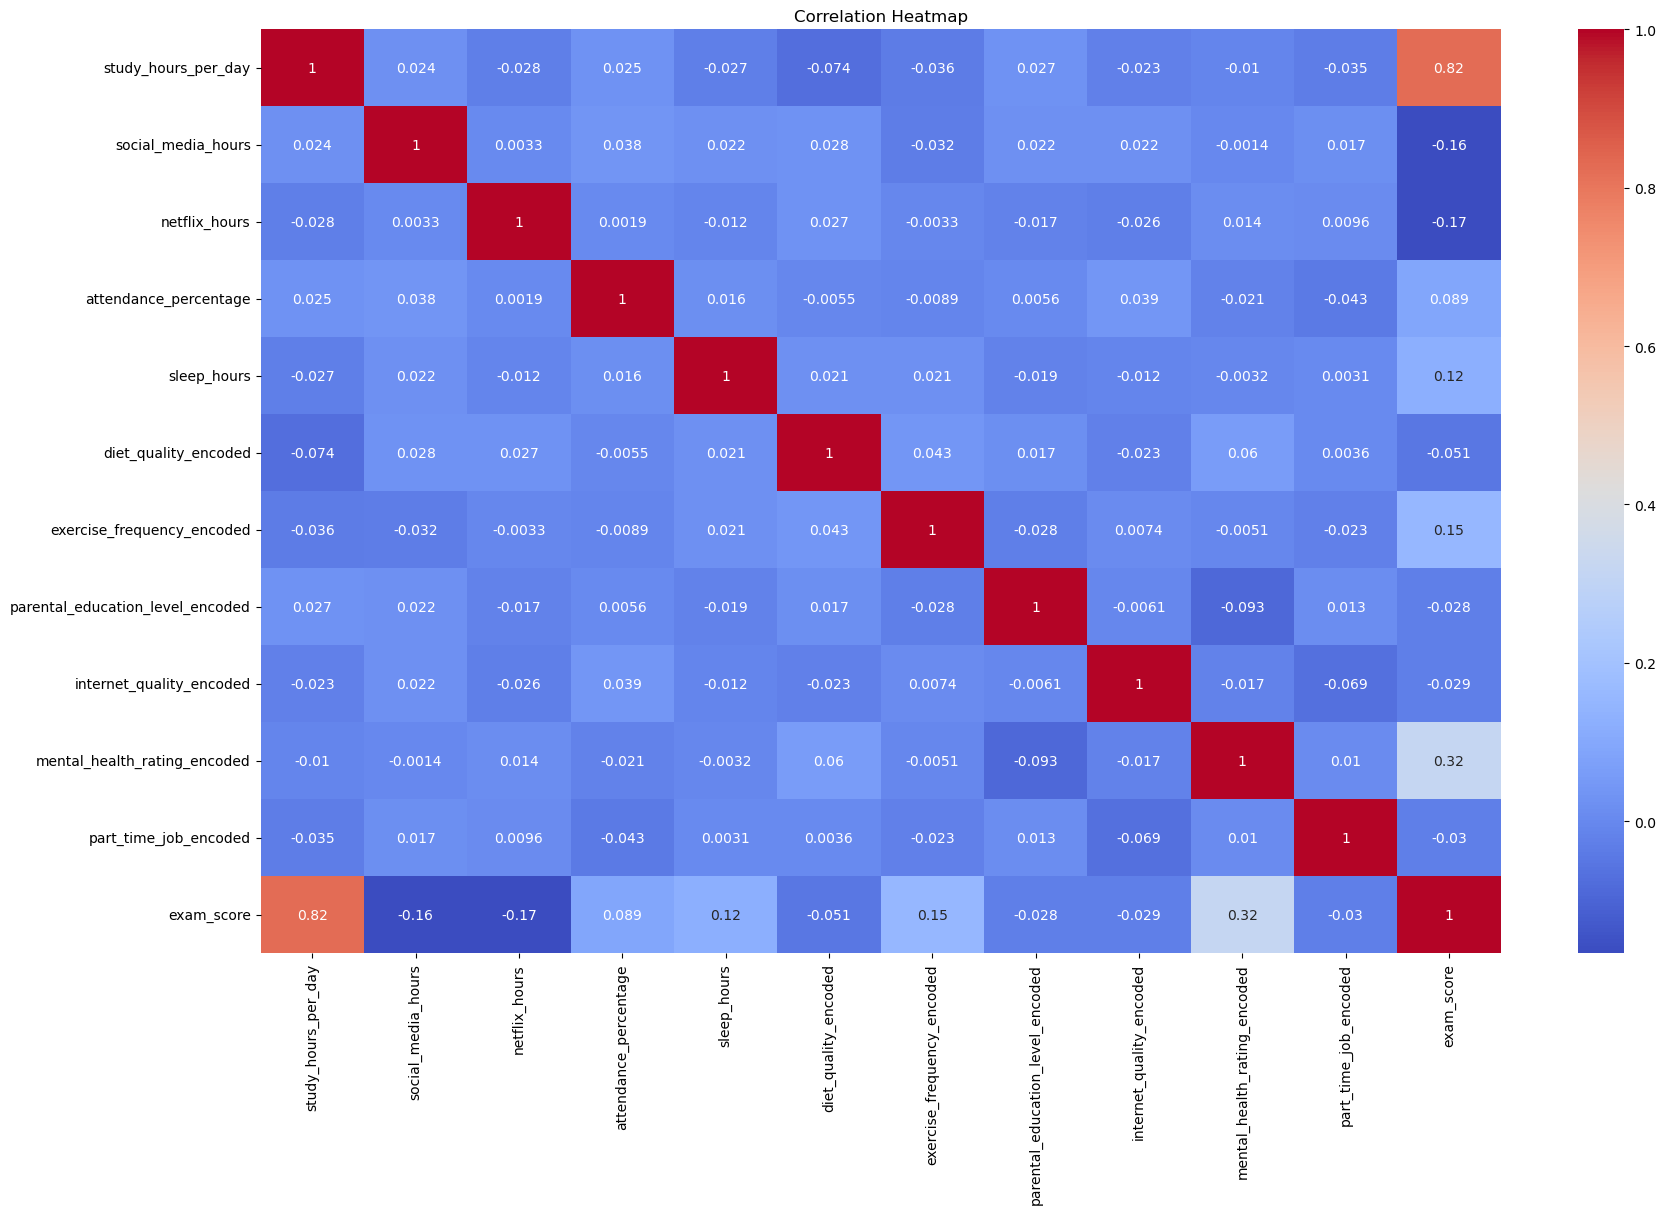

In [67]:
plt.figure(figsize=(20,12))
sns.heatmap(corr1, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [68]:
# 

In [69]:
corr2 = encoded_df.corr()
corr2

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exam_score,part_time_job_encoded,diet_quality_encoded,exercise_frequency_encoded,parental_education_level_encoded,internet_quality_encoded,mental_health_rating_encoded,extracurricular_participation_encoded,gender_Female,gender_Male,gender_Other
age,1.000000,0.002040,-0.005712,-0.009651,-0.024413,0.032116,-0.011105,-0.008366,-0.012171,-0.003860,-0.003265,0.042176,-0.041915,-0.003796,-0.035933,0.029706,0.015477
study_hours_per_day,0.002040,1.000000,0.023837,-0.027636,0.024766,-0.026648,0.824307,-0.034839,-0.074233,-0.035924,0.027204,-0.022978,-0.010456,-0.009227,0.032336,-0.036231,0.009634
social_media_hours,-0.005712,0.023837,1.000000,0.003324,0.037690,0.021721,-0.164083,0.016794,0.027555,-0.032397,0.022447,0.022271,-0.001422,-0.016377,0.000650,-0.008158,0.018621
netflix_hours,-0.009651,-0.027636,0.003324,1.000000,0.001854,-0.011618,-0.167123,0.009620,0.026614,-0.003318,-0.017189,-0.026247,0.013591,0.005060,-0.029411,0.009758,0.048772
attendance_percentage,-0.024413,0.024766,0.037690,0.001854,1.000000,0.015544,0.088507,-0.042875,-0.005453,-0.008941,0.005647,0.038577,-0.020918,-0.019412,0.026878,-0.026428,-0.001139
sleep_hours,0.032116,-0.026648,0.021721,-0.011618,0.015544,1.000000,0.124239,0.003116,0.020599,0.020557,-0.018775,-0.011734,-0.003169,0.031653,-0.003403,-0.019740,0.057406
exam_score,-0.011105,0.824307,-0.164083,-0.167123,0.088507,0.124239,1.000000,-0.029515,-0.050932,0.152952,-0.028263,-0.029373,0.319113,-0.006180,0.016695,-0.021844,0.012758
part_time_job_encoded,-0.008366,-0.034839,0.016794,0.009620,-0.042875,0.003116,-0.029515,1.000000,0.003649,-0.022902,0.013092,-0.069479,0.010360,-0.020290,-0.031546,0.026731,0.011971
diet_quality_encoded,-0.012171,-0.074233,0.027555,0.026614,-0.005453,0.020599,-0.050932,0.003649,1.000000,0.042532,0.017297,-0.022743,0.060216,0.061706,0.008583,-0.015809,0.017915
exercise_frequency_encoded,-0.003860,-0.035924,-0.032397,-0.003318,-0.008941,0.020557,0.152952,-0.022902,0.042532,1.000000,-0.028161,0.007437,-0.005083,-0.007114,-0.062935,0.066894,-0.009766


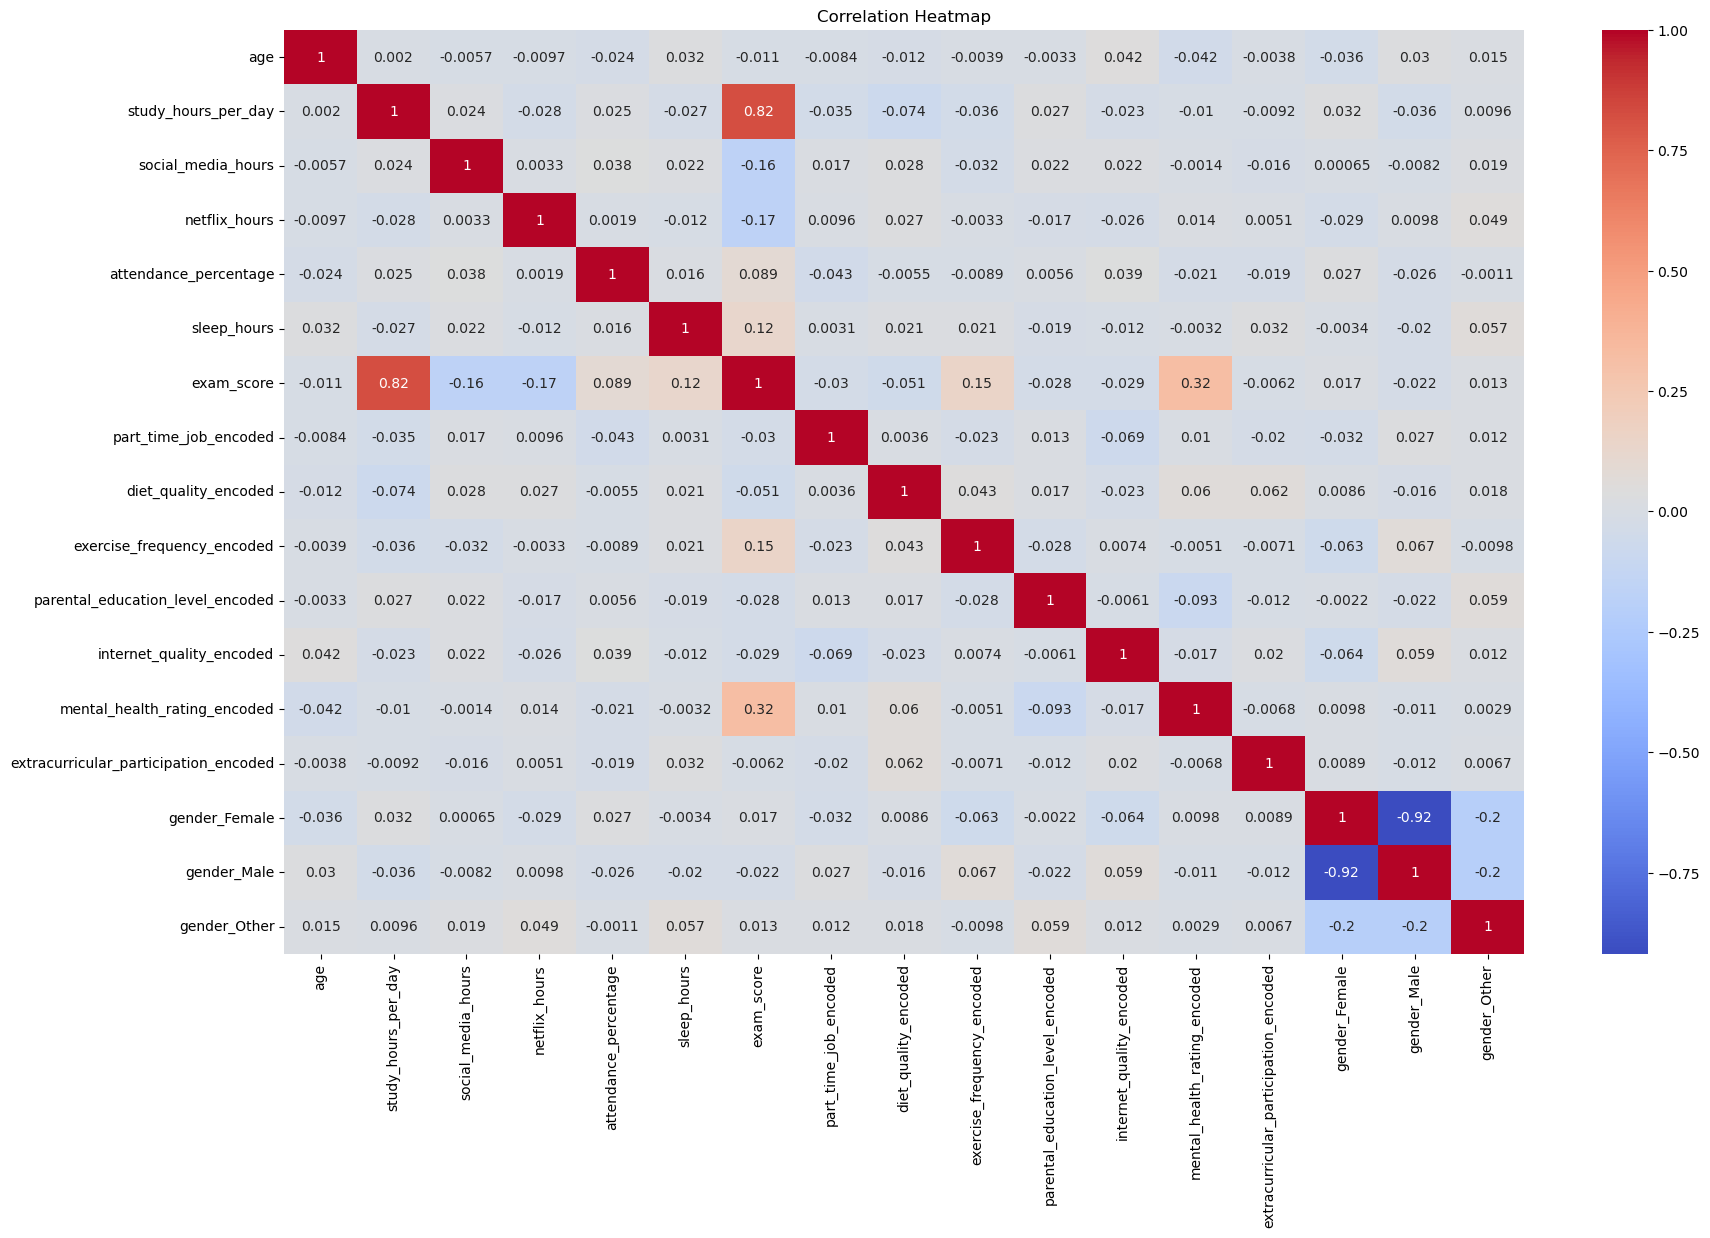

In [70]:
plt.figure(figsize=(20,12))
sns.heatmap(corr2, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [71]:
encoded_df['exam_score'].dtypes

dtype('float64')

In [72]:
corr_df = encoded_df.corr()[['exam_score']].sort_values(by='exam_score', ascending=False)
corr_df.style.background_gradient(axis=None)

,exam_score
exam_score,1.000000
study_hours_per_day,0.824307
mental_health_rating_encoded,0.319113
exercise_frequency_encoded,0.152952
sleep_hours,0.124239
attendance_percentage,0.088507
gender_Female,0.016695
gender_Other,0.012758
extracurricular_participation_encoded,-0.006180
age,-0.011105


In [73]:
# Ques 2 : How strongly do academic habits (study hours, attendance) affect exam scores?

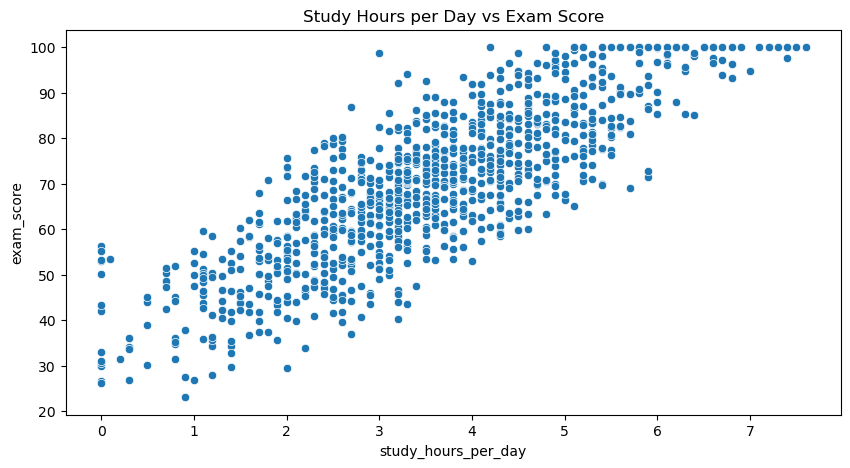

In [74]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='study_hours_per_day', y='exam_score')
plt.title('Study Hours per Day vs Exam Score')
plt.show()

In [75]:
#

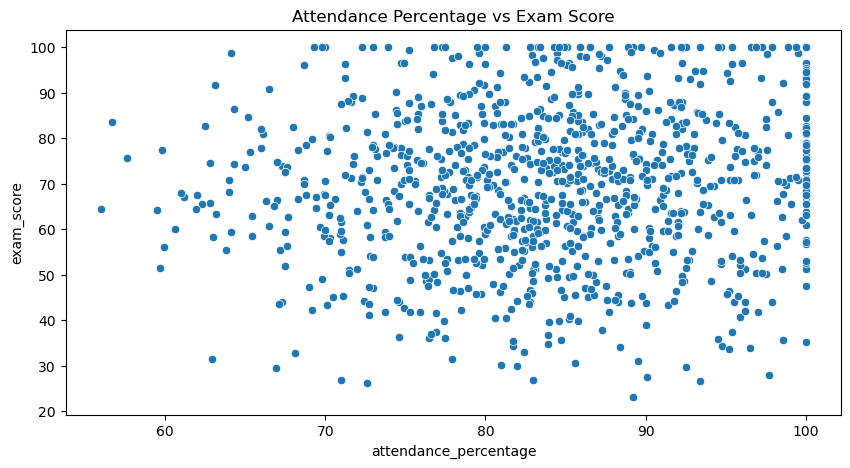

In [76]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='attendance_percentage', y='exam_score')
plt.title('Attendance Percentage vs Exam Score')
plt.show()

In [77]:
#

In [78]:
# Ques 3 : How do non-academic behaviors (social media usage, Netflix time, sleep patterns) impact exam scores?

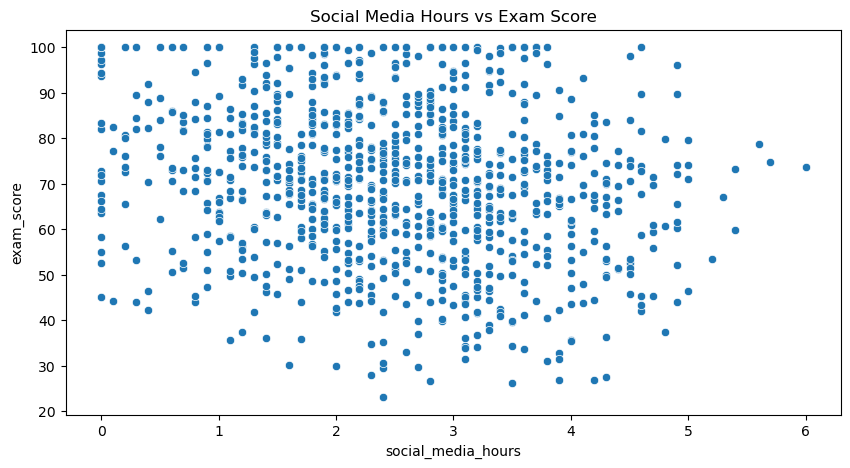

In [79]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='social_media_hours', y='exam_score')
plt.title('Social Media Hours vs Exam Score')
plt.show()

In [80]:
#

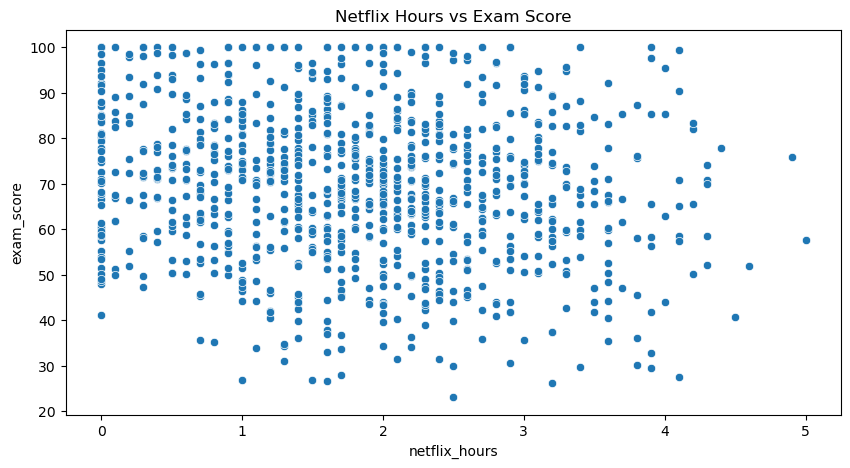

In [81]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='netflix_hours', y='exam_score')
plt.title('Netflix Hours vs Exam Score')
plt.show()

In [82]:
#

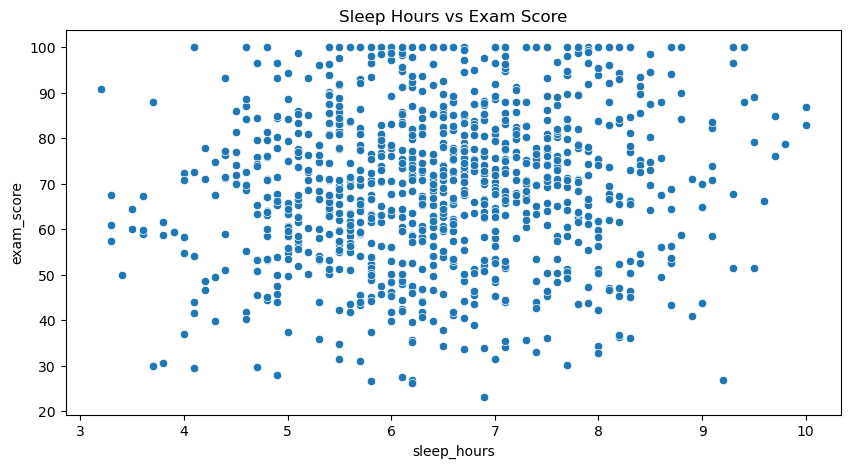

In [83]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='sleep_hours', y='exam_score')
plt.title('Sleep Hours vs Exam Score')
plt.show()

In [84]:
#

In [85]:
# Ques 4 : Does family background (parental education level, internet quality at home) impact exam scores?

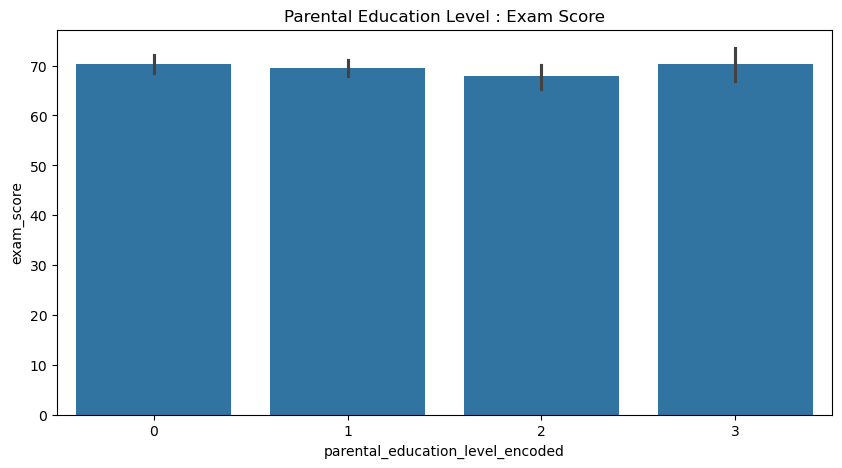

In [86]:
plt.figure(figsize=(10,5))
sns.barplot(encoded_df, x='parental_education_level_encoded', y='exam_score')
plt.title('Parental Education Level : Exam Score')
plt.show()

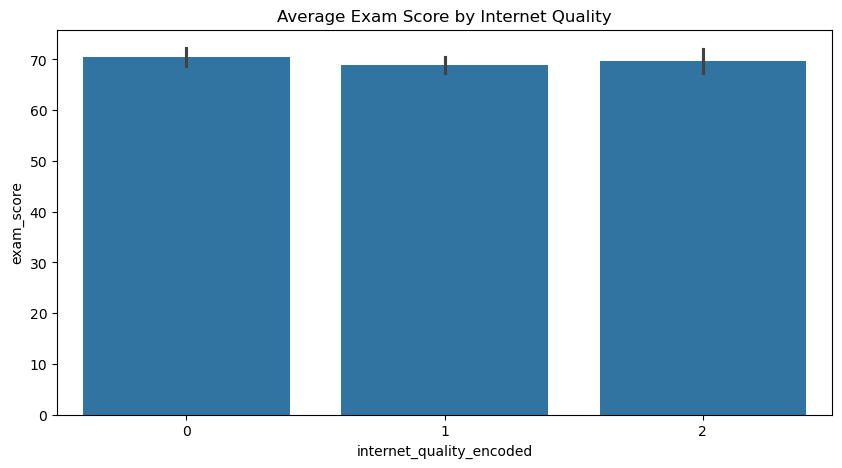

In [87]:
plt.figure(figsize=(10,5))
sns.barplot(encoded_df, x='internet_quality_encoded', y='exam_score')
plt.title('Average Exam Score by Internet Quality')
plt.show()

In [88]:
# Ques 5 : How does mental health relate to exam scores?

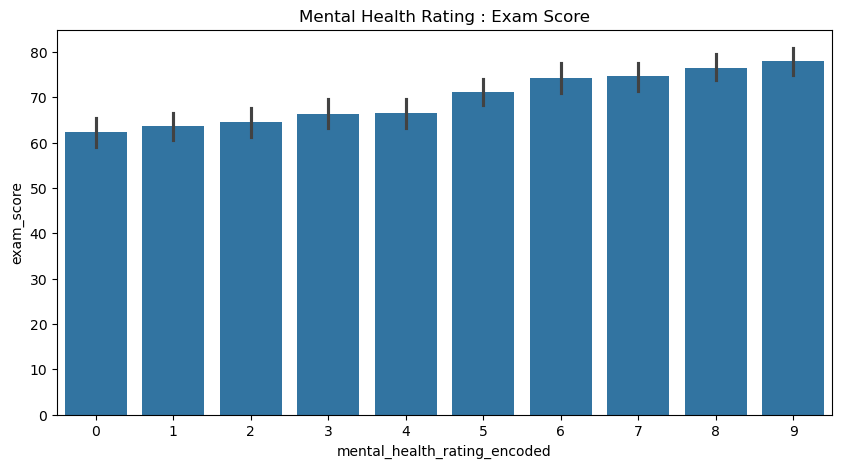

In [89]:
plt.figure(figsize=(10,5))
sns.barplot(encoded_df, x='mental_health_rating_encoded', y='exam_score')
plt.title('Mental Health Rating : Exam Score')
plt.show()

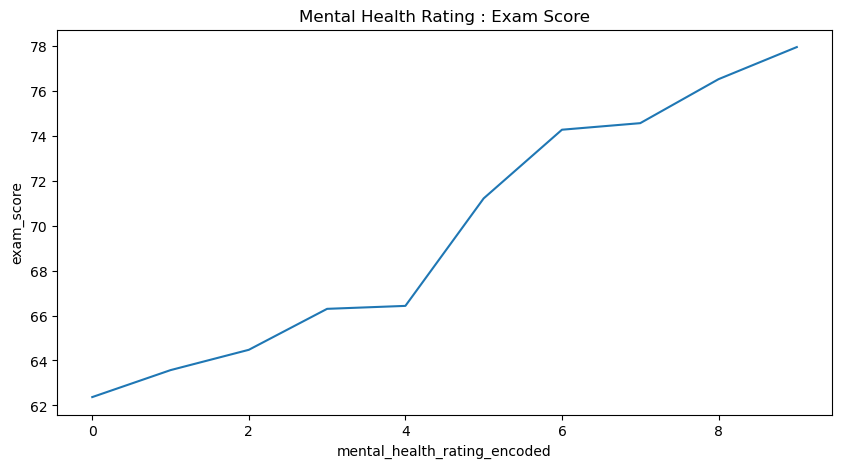

In [90]:
plt.figure(figsize=(10,5))
avg_health = encoded_df.groupby('mental_health_rating_encoded')['exam_score'].mean().reset_index()
sns.lineplot(avg_health, x='mental_health_rating_encoded', y='exam_score')
plt.title('Mental Health Rating : Exam Score')
plt.show()

## Modeling

In [92]:
# linear regression
x = encoded_df.drop(['exam_score'],axis=1)
y = encoded_df.exam_score

In [93]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=21)

In [94]:
scaler = StandardScaler()

In [95]:
X_trains = scaler.fit_transform(X_train)
X_tests = scaler.transform(X_test)

In [96]:
lr_model = LinearRegression()

In [97]:
lr_model.fit(X_trains,y_train)

LinearRegression()

In [98]:
y_pred = lr_model.predict(X_tests)

In [99]:
performance_table = evaluate_model_with_cross_validation(model=lr_model,X=X_trains,y=y_train)

In [100]:
performance_table

,Metric,Value,Threshold,Calculation,Performance
0,RMSE,5.178508,< 10%–20% of range,5.1785 / 76.90 * 100 ≈ 6.73%,Excellent
1,MAE,4.182818,< 10%–20% of range,4.1828 / 76.90 * 100 ≈ 5.44%,Excellent
2,R²,0.904931,"> 0.7 = Good, 0.5–0.7 = Acceptable, < 0.5 = Poor",N/A (unitless),Good
3,Explained Variance,0.906237,"> 0.7 = Good, 0.5–0.7 = Acceptable, < 0.5 = Poor",N/A (unitless),Good


In [101]:
plot_data = pd.DataFrame({'actual':y_test,'predicted':y_pred})

<Axes: xlabel='actual', ylabel='predicted'>

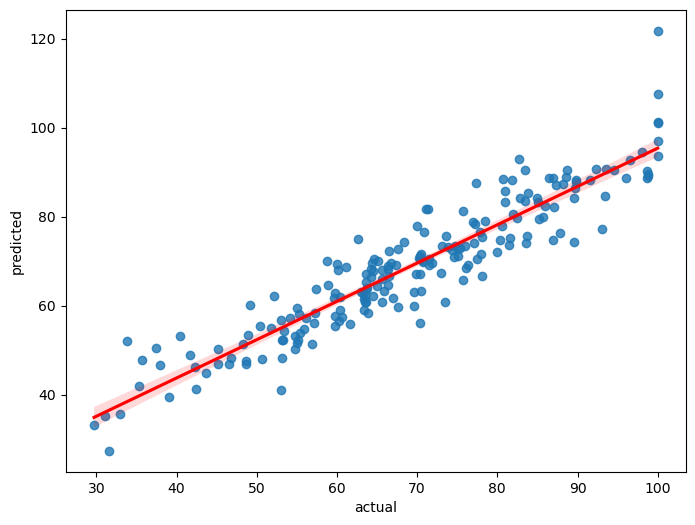

In [102]:
plt.figure(figsize=(8,6))
sns.regplot(data = plot_data, x='actual',y='predicted',line_kws={'color':'red'})

In [103]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'KNN Regression': KNeighborsRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'AdaBoost Regression': AdaBoostRegressor(),
    'XGBoost Regression':xgb.XGBRegressor(),
}

In [104]:
# Evaluate models
results = []
for name,model in models.items():
    pipeline = Pipeline([
        ('regressor',model),
    ])
    pipeline.fit(X_train,y_train)
    y_pred2 = pipeline.predict(X_test)
    results.append({
        'model':name,
        'R2_score': r2_score(y_test,y_pred2),
        'MSE': mean_squared_error(y_test,y_pred2)
    })

In [105]:
df1 = pd.DataFrame(results)
df1.sort_values(by='R2_score', ascending=False)

,model,R2_score,MSE
0,Linear Regression,0.865954,35.717189
1,Ridge Regression,0.865945,35.719676
2,Lasso Regression,0.857185,38.053836
6,Random Forest Regression,0.840387,42.529890
8,XGBoost Regression,0.825344,46.538014
7,AdaBoost Regression,0.779344,58.795009
4,Decision Tree Regression,0.654319,92.108693
5,KNN Regression,0.518378,128.330913
3,Support Vector Regression,0.034179,257.348390


## Add ensemble model (Voting Regressor)

In [107]:
voting = VotingRegressor(estimators=[
    ('linearRegression', LinearRegression()),
    ('ridge', Ridge()),
    ('lasso', Lasso())
])

In [108]:
results = []
for name,model in [('voting regressor', voting)]:
    pipeline = Pipeline([
        ('regressor',model),
    ])
    pipeline.fit(X_train,y_train)
    y_pred3 = pipeline.predict(X_test)
    results.append({
        'model':name,
        'R2_score': r2_score(y_test,y_pred3),
        'MSE': mean_squared_error(y_test,y_pred3)
    })

In [109]:
df2 = pd.DataFrame(results)
df2.sort_values(by='R2_score', ascending=False)

,model,R2_score,MSE
0,voting regressor,0.866132,35.67


## Test

In [247]:
model_ = {
    'model':lr_model,
    'scaler': scaler, 
    'feature_names':x.columns.tolist(),
}

In [249]:
joblib.dump(model_,'exam_score_model2.joblib')

['exam_score_model2.joblib']

In [251]:
## end of test

## Saving the model file

In [254]:
import joblib

In [256]:
joblib.dump(lr_model,'exam_score_model.joblib')

['exam_score_model.joblib']

In [258]:
# x.columns

## Quick demo

In [261]:
import gradio as gr
print(gr.__version__)

5.25.2


In [263]:
x

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,part_time_job_encoded,diet_quality_encoded,exercise_frequency_encoded,parental_education_level_encoded,internet_quality_encoded,mental_health_rating_encoded,extracurricular_participation_encoded,gender_Female,gender_Male,gender_Other
0,23,0.0,1.2,1.1,85.0,8.0,0,0,6,2,0,7,1,1.0,0.0,0.0
1,20,6.9,2.8,2.3,97.3,4.6,0,1,6,1,0,7,0,1.0,0.0,0.0
2,21,1.4,3.1,1.3,94.8,8.0,0,2,1,1,2,0,0,0.0,1.0,0.0
3,23,1.0,3.9,1.0,71.0,9.2,0,2,4,2,1,0,1,1.0,0.0,0.0
4,19,5.0,4.4,0.5,90.9,4.9,0,0,3,2,1,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,21,2.6,0.5,1.6,77.0,7.5,0,0,2,1,1,5,1,1.0,0.0,0.0
988,17,2.9,1.0,2.4,86.0,6.8,1,2,1,1,0,5,1,1.0,0.0,0.0
989,20,3.0,2.6,1.3,61.9,6.5,0,1,5,0,1,8,1,0.0,1.0,0.0
990,24,5.4,4.1,1.1,100.0,7.6,1,0,0,0,0,0,0,0.0,1.0,0.0


In [265]:
x.columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'part_time_job_encoded',
       'diet_quality_encoded', 'exercise_frequency_encoded',
       'parental_education_level_encoded', 'internet_quality_encoded',
       'mental_health_rating_encoded', 'extracurricular_participation_encoded',
       'gender_Female', 'gender_Male', 'gender_Other'],
      dtype='object')

In [267]:
model = joblib.load('exam_score_model2.joblib')
model

{'model': LinearRegression(),
 'scaler': StandardScaler(),
 'feature_names': ['age',
  'study_hours_per_day',
  'social_media_hours',
  'netflix_hours',
  'attendance_percentage',
  'sleep_hours',
  'part_time_job_encoded',
  'diet_quality_encoded',
  'exercise_frequency_encoded',
  'parental_education_level_encoded',
  'internet_quality_encoded',
  'mental_health_rating_encoded',
  'extracurricular_participation_encoded',
  'gender_Female',
  'gender_Male',
  'gender_Other']}

In [283]:
model = joblib.load('exam_score_model2.joblib')
lr_model = model['model']
scaler = model['scaler']
features_names = model['feature_names']

def predict_exam_score(age, study_hours_per_day, social_media_hours, netflix_hours, attendance_percentage, sleep_hours, part_time_job, diet_quality, exercise_frequency, parental_education_level, internet_quality, mental_health_rating, extracurricular_participation, gender):
    diet_quality_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
    internet_quality_map = {'Poor': 0, 'Average': 1, 'Good': 2}
    part_time_job_map = {'No': 0, 'Yes': 1}
    parental_education_map = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'Unknown': 3}
    extracurricular_map = {'No': 0, 'Yes': 1}
    
    gender_female = 1 if gender == 'Female' else 0
    gender_male = 1 if gender == 'Male' else 0
    gender_other = 1 if gender == 'Other' else 0
    
    input_data = pd.DataFrame({
        'age': [age],
        'study_hours_per_day': [study_hours_per_day],
        'social_media_hours': [social_media_hours],
        'netflix_hours': [netflix_hours],
        'attendance_percentage': [attendance_percentage],
        'sleep_hours': [sleep_hours],
        'part_time_job_encoded': [part_time_job_map[part_time_job]],
        'diet_quality_encoded': [diet_quality_map[diet_quality]],
        'exercise_frequency_encoded': [exercise_frequency],
        'parental_education_level_encoded': [parental_education_map[parental_education_level]],
        'internet_quality_encoded': [internet_quality_map[internet_quality]],
        'mental_health_rating_encoded': [mental_health_rating],
        'extracurricular_participation_encoded': [extracurricular_map[extracurricular_participation]],
        'gender_Female': [gender_female],
        'gender_Male': [gender_male],
        'gender_Other': [gender_other],
    })

    input_scaled = scaler.transform(input_data)
    prediction = lr_model.predict(input_scaled)[0]
    prediction = max(0, min(100, prediction))
    return f"{prediction:.2f} scores"

with gr.Blocks(title='Predict Exam Score Demo') as demo:
    gr.Markdown('Exam Score Prediction')
    with gr.Row():
        with gr.Column():
            age = gr.Slider(18, 30, step=1, label='Age')
            study_hours_per_day = gr.Slider(0, 10, step=0.5, label='Study Hours Per Day')
            social_media_hours = gr.Slider(0, 10, step=0.5, label='Social Media Hours per Day')
            netflix_hours = gr.Slider(0, 10, step=0.5, label='Netflix Hours per Day')
            attendance_percentage = gr.Slider(0, 100, step=1, label='Attendance Percentage (%)')
            sleep_hours = gr.Slider(0, 12, step=0.5, label='Sleep Hours Per Night')
            
            part_time_job = gr.Radio(
                choices=['Yes', 'No'], 
                label='Part-Time Job',
            )
            
            diet_quality = gr.Radio(
                choices=['Poor', 'Fair', 'Good'],
                label='Diet Quality',
            )
            
            exercise_frequency = gr.Slider(0, 7, step=1, label='Exercise Days per Week')
            
            parental_education_level = gr.Radio(
                choices=['High School', 'Bachelor', 'Master', 'Unknown'], 
                label='Parental Education Level',
            )
            
            internet_quality = gr.Radio(
                choices=['Poor', 'Average', 'Good'], 
                label='Internet Quality at Home',
            )
            
            mental_health_rating = gr.Slider(1, 10, step=1, label='Mental Health Rating (1-10)')
            
            extracurricular_participation = gr.Radio(
                choices=['Yes', 'No'], 
                label='Extracurricular Participation',
            )
            
            gender = gr.Radio(
                choices=['Female', 'Male', 'Other'],
                label='Gender',
            )

            predict_button = gr.Button('Predict Exam Score')
            prediction_output = gr.Textbox(label='Predicted Exam Score', value="Click Predict to see result")

    predict_button.click(
        fn=predict_exam_score,
        inputs=[age, study_hours_per_day, social_media_hours, netflix_hours, attendance_percentage,sleep_hours, part_time_job, diet_quality, exercise_frequency,parental_education_level, internet_quality, mental_health_rating,extracurricular_participation, gender],
        outputs=prediction_output
    )

if __name__ == '__main__':
    demo.launch()

* Running on local URL:  http://127.0.0.1:7874

To create a public link, set `share=True` in `launch()`.
